# Marginal MCMC — PROMIS Neuropathic Pain (Factorized GRM)

Runs NUTS on item parameters with abilities Rao-Blackwellized out
for three model variants: baseline, pairwise imputation, and mixed imputation.
Data from Harvard Dataverse (doi:10.7910/DVN/TJ9MNM).

In [1]:
%load_ext autoreload
%autoreload 2

import gc
import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
from bayesianquilts.data.promis_neuropathic_pain import get_multidomain_data, item_keys, response_cardinality

df, num_people, scale_indices = get_multidomain_data(polars_out=True, min_items=10)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {len(scale_indices)} domains")
for domain, indices in scale_indices.items():
    print(f"  {domain}: {len(indices)} items")

def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        data[col] = dataframe[col].to_numpy().astype(np.float64)
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

base_data = make_data_dict(df)

BATCH_SIZE = 256
def data_factory():
    indices = np.arange(num_people)
    np.random.shuffle(indices)
    for start in range(0, num_people, BATCH_SIZE):
        end = min(start + BATCH_SIZE, num_people)
        yield {k: v[indices[start:end]] for k, v in base_data.items()}

Auto-selected 3 domains with ≥10 items: ['pain_interference', 'pain_behavior', 'global_health']
  pain_interference: 36 items (indices 0-35)
  pain_behavior: 37 items (indices 36-72)
  global_health: 10 items (indices 73-82)
Total: 83 items across 3 domains
Dataset: 963 people, 83 items, 3 domains
  pain_interference: 36 items
  pain_behavior: 37 items
  global_health: 10 items


## 2. Load Pairwise Stacking Model

In [3]:
from bayesianquilts.irt.factorizedgrm import FactorizedGRModel
from pathlib import Path
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

pairwise_model = None
pairwise_path = Path('pairwise_stacking_model.yaml')
if pairwise_path.exists():
    pairwise_model = PairwiseOrdinalStackingModel.load(str(pairwise_path))
    print(f"Loaded pairwise stacking model: {len(pairwise_model.variable_names)} variables")
else:
    print("No pairwise stacking model found — only baseline variant will run")

Loaded pairwise stacking model: 83 variables


## 3. MCMC Helper

In [4]:
NUM_CHAINS = 4
NUM_WARMUP = 1000
NUM_SAMPLES = 500
STEP_SIZE = 0.001

def run_variant(variant_name, model, data, seed):
    print(f"\n=== {variant_name.upper()} ===")
    mcmc_samples = model.fit_marginal_mcmc(
        data,
        theta_grid=None,
        num_chains=NUM_CHAINS,
        num_warmup=NUM_WARMUP,
        num_samples=NUM_SAMPLES,
        target_accept_prob=0.85,
        step_size=STEP_SIZE,
        seed=seed,
        verbose=True,
    )

    eap_result = model.compute_eap_abilities(data)
    eap = np.array(eap_result['eap'])
    print(f"  EAP: mean={np.mean(eap):.4f}, std={np.std(eap):.4f}")

    stats = model.standardize_marginal(data)
    eap_result = model.compute_eap_abilities(data)
    eap_std = np.array(eap_result['eap'])
    print(f"  Post-std EAP: mean={np.mean(eap_std):.4f}, std={np.std(eap_std):.4f}")

    model.fit_surrogate_to_mcmc()
    eap_arr = np.array(eap_result['eap'])
    model.surrogate_sample['abilities'] = jnp.array(
        eap_arr[:, np.newaxis, np.newaxis, np.newaxis]
    )[np.newaxis, ...]

    model.save_to_disk(f'grm_mcmc_{variant_name}')

    os.makedirs('mcmc_samples', exist_ok=True)
    save_dict = {}
    for var_name, samples in mcmc_samples.items():
        save_dict[var_name] = np.array(samples)
        flat = np.array(samples).reshape(-1, *samples.shape[2:])
        print(f"  {var_name}: mean={np.mean(flat):.4f}, std={np.std(flat):.4f}")
        if samples.shape[0] > 1:
            chain_means = np.mean(np.array(samples), axis=1)
            between_var = np.var(chain_means, axis=0, ddof=1)
            within_var = np.mean(np.var(np.array(samples), axis=1, ddof=1), axis=0)
            n = samples.shape[1]
            r_hat = np.sqrt(((n - 1) / n * within_var + between_var) / np.maximum(within_var, 1e-30))
            print(f"    R-hat: mean={np.mean(r_hat):.4f}, max={np.max(r_hat):.4f}")
    save_dict['eap'] = eap
    save_dict['eap_standardized'] = eap_std
    save_dict['psd'] = np.array(eap_result['psd'])
    save_dict['standardize_mu'] = stats['mu']
    save_dict['standardize_sigma'] = stats['sigma']
    np.savez(f'mcmc_samples/mcmc_{variant_name}.npz', **save_dict)

    return eap_std, np.array(eap_result['psd'])

## 4. Baseline MCMC (No Imputation)

In [5]:
model = FactorizedGRModel.load_from_disk('grm_baseline')
data = dict(base_data)
eap_baseline, psd_baseline = run_variant('baseline', model, data, seed=42)
del model; gc.collect()


=== BASELINE ===
Marginal MCMC (Rao-Blackwellized abilities)
  Item params: ['discriminations_0', 'mu_0', 'difficulties0_0', 'ddifficulties_0', 'discriminations_1', 'mu_1', 'difficulties0_1', 'ddifficulties_1', 'discriminations_2', 'mu_2', 'difficulties0_2', 'ddifficulties_2']


  Total dimensions: 498
  Quadrature: 31-point Gauss-Hermite
  Chains: 4, Warmup: 500, Samples: 500


  Initializing from ADVI solution


  Flat parameter vector: 498 elements



  Chain 1/4:


...

  ddifficulties_2: mean=2.6523, std=1.1650


  EAP: mean=0.0766, std=0.8229
  Standardizing marginal: mu=0.0766, sigma=0.8229


  Post-std EAP: mean=0.0038, std=0.9768


  Surrogate fitted to MCMC (12 variables)
    discriminations_0: loc=1.8669, scale=1.0142
    mu_0: loc=-1.5167, scale=1.2927
    difficulties0_0: loc=-1.1951, scale=0.9457
    ddifficulties_0: loc=0.8899, scale=0.4898
    discriminations_1: loc=1.5957, scale=0.5537
    mu_1: loc=-1.7920, scale=1.1152
    difficulties0_1: loc=-1.8937, scale=1.1523
    ddifficulties_1: loc=1.0074, scale=0.6216
    discriminations_2: loc=0.7407, scale=0.6587
    mu_2: loc=-2.3645, scale=1.3602
    difficulties0_2: loc=-4.5408, scale=1.8442
    ddifficulties_2: loc=3.2233, scale=1.4158
  discriminations_0: mean=1.8669, std=1.0142
    R-hat: mean=3.3113, max=9.9831
  mu_0: mean=-1.5167, std=1.2927
    R-hat: mean=3.5040, max=7.9717
  difficulties0_0: mean=-1.1951, std=0.9457
    R-hat: mean=2.8837, max=8.1411
  ddifficulties_0: mean=0.8899, std=0.4898
    R-hat: mean=2.9223, max=9.8016
  discriminations_1: mean=1.5957, std=0.5537
    R-hat: mean=3.5942, max=7.6474
  mu_1: mean=-1.7920, std=1.1152
    R-hat

120

## 5. Pairwise MCMC (Pairwise Stacking Imputation)

In [6]:
if pairwise_model is not None:
    model = FactorizedGRModel.load_from_disk('grm_baseline')
    model.imputation_model = pairwise_model
    data = dict(base_data)
    pmfs, weights = model._compute_batch_pmfs(data)
    if pmfs is not None:
        data['_imputation_pmfs'] = pmfs
    print("Pairwise imputation PMFs attached")
    eap_pairwise, psd_pairwise = run_variant('pairwise', model, data, seed=43)
    del model; gc.collect()
else:
    print("Skipping — no pairwise model available")
    eap_pairwise = psd_pairwise = None

Pairwise imputation PMFs attached

=== PAIRWISE ===
Marginal MCMC (Rao-Blackwellized abilities)
  Item params: ['discriminations_0', 'mu_0', 'difficulties0_0', 'ddifficulties_0', 'discriminations_1', 'mu_1', 'difficulties0_1', 'ddifficulties_1', 'discriminations_2', 'mu_2', 'difficulties0_2', 'ddifficulties_2']


  Total dimensions: 498
  Quadrature: 31-point Gauss-Hermite
  Chains: 4, Warmup: 500, Samples: 500


  Initializing from ADVI solution


  Flat parameter vector: 498 elements



  Chain 1/4:


...

    Non-divergent ratio: 0.000



  Kept 4/4 chains
  Mean non-divergent: 0.000
  discriminations_0: mean=2.2415, std=1.2636
  mu_0: mean=-1.2519, std=1.0570
  difficulties0_0: mean=-0.8529, std=0.7911
  ddifficulties_0: mean=0.7257, std=0.4201
  discriminations_1: mean=1.9453, std=0.6681
  mu_1: mean=-1.4230, std=1.0283
  difficulties0_1: mean=-1.4302, std=0.9869
  ddifficulties_1: mean=0.8551, std=0.5203
  discriminations_2: mean=0.8857, std=0.7838
  mu_2: mean=-1.8491, std=1.1047
  difficulties0_2: mean=-3.6940, std=1.5606
  ddifficulties_2: mean=2.7131, std=1.2078


  EAP: mean=0.1140, std=0.8163


  Standardizing marginal: mu=0.1140, sigma=0.8163


  Post-std EAP: mean=0.0052, std=0.9756
  Surrogate fitted to MCMC (12 variables)
    discriminations_0: loc=1.8297, scale=1.0315
    mu_0: loc=-1.6732, scale=1.2948
    difficulties0_0: loc=-1.1844, scale=0.9691
    ddifficulties_0: loc=0.8890, scale=0.5147
    discriminations_1: loc=1.5879, scale=0.5454
    mu_1: loc=-1.8828, scale=1.2598
    difficulties0_1: loc=-1.8917, scale=1.2090
    ddifficulties_1: loc=1.0476, scale=0.6374
    discriminations_2: loc=0.7230, scale=0.6398
    mu_2: loc=-2.4049, scale=1.3533
    difficulties0_2: loc=-4.6649, scale=1.9118
    ddifficulties_2: loc=3.3237, scale=1.4797
  discriminations_0: mean=1.8297, std=1.0315
    R-hat: mean=3.1835, max=14.3329
  mu_0: mean=-1.6732, std=1.2948
    R-hat: mean=3.7169, max=9.0064
  difficulties0_0: mean=-1.1844, std=0.9691
    R-hat: mean=3.0092, max=7.6969
  ddifficulties_0: mean=0.8890, std=0.5147
    R-hat: mean=2.4046, max=7.7135
  discriminations_1: mean=1.5879, std=0.5454
    R-hat: mean=3.0191, max=7.0490
 

## 6. Mixed MCMC (Pairwise + IRT Imputation)

In [7]:
if pairwise_model is not None:
    from bayesianquilts.imputation.mixed import IrtMixedImputationModel
    model = FactorizedGRModel.load_from_disk('grm_baseline')

    surrogate = model.surrogate_distribution_generator(model.params)
    samples = surrogate.sample(32, seed=jax.random.PRNGKey(142))
    model.surrogate_sample = samples
    model.calibrated_expectations = {
        k: jnp.mean(v, axis=0) for k, v in samples.items()
    }

    mixed_model = IrtMixedImputationModel(
        irt_model=model,
        mice_model=pairwise_model,
        data_factory=data_factory,
        irt_elpd_batch_size=4,
    )
    model.imputation_model = mixed_model

    data = dict(base_data)
    pmfs, weights = model._compute_batch_pmfs(data)
    if pmfs is not None:
        data['_imputation_pmfs'] = pmfs
        if weights is not None:
            data['_imputation_weights'] = weights
    print("Mixed imputation PMFs attached")
    eap_mixed, psd_mixed = run_variant('mixed', model, data, seed=44)
    del model, mixed_model; gc.collect()
else:
    print("Skipping — no pairwise model available")
    eap_mixed = psd_mixed = None

MICE pointwise ELPD computed for 83 items, 963 people


Mixed imputation PMFs attached

=== MIXED ===
Marginal MCMC (Rao-Blackwellized abilities)
  Item params: ['discriminations_0', 'mu_0', 'difficulties0_0', 'ddifficulties_0', 'discriminations_1', 'mu_1', 'difficulties0_1', 'ddifficulties_1', 'discriminations_2', 'mu_2', 'difficulties0_2', 'ddifficulties_2']


  Total dimensions: 498
  Quadrature: 31-point Gauss-Hermite
  Chains: 4, Warmup: 500, Samples: 500


  Initializing from ADVI solution


  Flat parameter vector: 498 elements


...

    Non-divergent ratio: 0.000



  Kept 4/4 chains
  Mean non-divergent: 0.000
  discriminations_0: mean=2.4196, std=1.3270
  mu_0: mean=-1.1466, std=0.9568
  difficulties0_0: mean=-0.4738, std=1.4865
  ddifficulties_0: mean=0.7342, std=0.5299
  discriminations_1: mean=1.9770, std=0.8940
  mu_1: mean=-1.4121, std=1.0444
  difficulties0_1: mean=-1.3709, std=1.3505
  ddifficulties_1: mean=0.9119, std=0.7472
  discriminations_2: mean=1.0770, std=1.0696
  mu_2: mean=-1.8228, std=1.1472
  difficulties0_2: mean=-3.6043, std=1.4290
  ddifficulties_2: mean=2.4300, std=1.1090


  EAP: mean=-0.1895, std=0.7415


  Standardizing marginal: mu=-0.1895, sigma=0.7415


  Post-std EAP: mean=-0.0045, std=0.9734
  Surrogate fitted to MCMC (12 variables)
    discriminations_0: loc=1.7941, scale=0.9839
    mu_0: loc=-1.2908, scale=1.2905
    difficulties0_0: loc=-0.3835, scale=2.0048
    ddifficulties_0: loc=0.9903, scale=0.7146
    discriminations_1: loc=1.4659, scale=0.6629
    mu_1: loc=-1.6490, scale=1.4086
    difficulties0_1: loc=-1.5933, scale=1.8213
    ddifficulties_1: loc=1.2298, scale=1.0077
    discriminations_2: loc=0.7986, scale=0.7931
    mu_2: loc=-2.2028, scale=1.5472
    difficulties0_2: loc=-4.6054, scale=1.9273
    ddifficulties_2: loc=3.2773, scale=1.4956
  discriminations_0: mean=1.7941, std=0.9839
    R-hat: mean=2.7073, max=6.5514
  mu_0: mean=-1.2908, std=1.2905
    R-hat: mean=3.2976, max=7.7409
  difficulties0_0: mean=-0.3835, std=2.0048
    R-hat: mean=2.8746, max=6.8056
  ddifficulties_0: mean=0.9903, std=0.7146
    R-hat: mean=2.4842, max=8.2874
  discriminations_1: mean=1.4659, std=0.6629
    R-hat: mean=2.9615, max=8.8590
 

## 7. Compare Variants

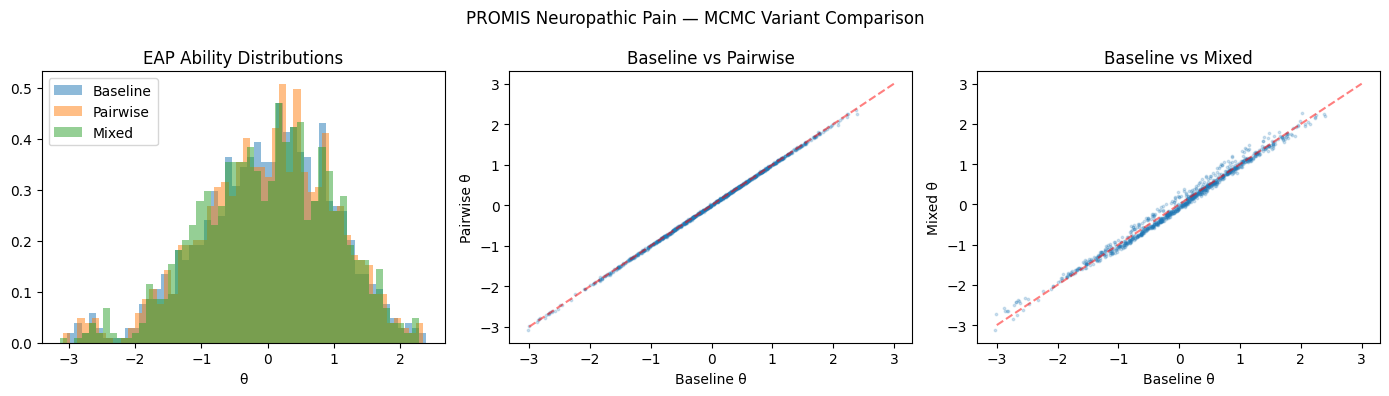

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# EAP distributions
for eap, label in [(eap_baseline, 'Baseline'), (eap_pairwise, 'Pairwise'), (eap_mixed, 'Mixed')]:
    if eap is not None:
        axes[0].hist(eap, bins=50, density=True, alpha=0.5, label=label)
axes[0].set_title('EAP Ability Distributions')
axes[0].set_xlabel('θ')
axes[0].legend()

# Baseline vs Pairwise scatter
if eap_pairwise is not None:
    axes[1].scatter(eap_baseline, eap_pairwise, alpha=0.2, s=3)
    axes[1].plot([-3, 3], [-3, 3], 'r--', alpha=0.5)
    axes[1].set_xlabel('Baseline θ')
    axes[1].set_ylabel('Pairwise θ')
    axes[1].set_title('Baseline vs Pairwise')

# Baseline vs Mixed scatter
if eap_mixed is not None:
    axes[2].scatter(eap_baseline, eap_mixed, alpha=0.2, s=3)
    axes[2].plot([-3, 3], [-3, 3], 'r--', alpha=0.5)
    axes[2].set_xlabel('Baseline θ')
    axes[2].set_ylabel('Mixed θ')
    axes[2].set_title('Baseline vs Mixed')

fig.suptitle('PROMIS Neuropathic Pain — MCMC Variant Comparison')
fig.tight_layout()
fig.savefig('mcmc_variant_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Summary

Ran marginal MCMC (NUTS with Rao-Blackwellized abilities) for three
model variants on PROMIS Neuropathic Pain:
- **Baseline**: ignorable missingness
- **Pairwise**: pairwise ordinal stacking imputation
- **Mixed**: pairwise + IRT blended imputation

4 chains × 500 samples each.